In [7]:
#https://arxiv.org/pdf/2108.01064
#https://huggingface.co/facebook/bart-large-mnli
#https://github.com/huggingface/sentence-transformers/blob/main/examples/sentence_transformer/applications/text-summarization/text_summarization.py
#https://www.goodnewsnetwork.org/category/news/business/

In [1]:
#так как я не смог импортнуть одну из библиотек, то перекопировал ее функции сюда. это для создания summary

import logging

import numpy as np
from scipy.sparse.csgraph import connected_components
from scipy.special import softmax

logger = logging.getLogger(__name__)


def degree_centrality_scores(similarity_matrix, threshold=None, increase_power=True):
    if not (threshold is None or isinstance(threshold, float) and 0 <= threshold < 1):
        raise ValueError(
            "'threshold' should be a floating-point number from the interval [0, 1) or None",
        )

    if threshold is None:
        markov_matrix = create_markov_matrix(similarity_matrix)

    else:
        markov_matrix = create_markov_matrix_discrete(
            similarity_matrix,
            threshold,
        )

    scores = stationary_distribution(
        markov_matrix,
        increase_power=increase_power,
        normalized=False,
    )

    return scores


def _power_method(transition_matrix, increase_power=True, max_iter=10000):
    eigenvector = np.ones(len(transition_matrix))

    if len(eigenvector) == 1:
        return eigenvector

    transition = transition_matrix.transpose()

    for _ in range(max_iter):
        eigenvector_next = np.dot(transition, eigenvector)

        if np.allclose(eigenvector_next, eigenvector):
            return eigenvector_next

        eigenvector = eigenvector_next

        if increase_power:
            transition = np.dot(transition, transition)

    logger.warning("Maximum number of iterations for power method exceeded without convergence!")
    return eigenvector_next


def connected_nodes(matrix):
    _, labels = connected_components(matrix)

    groups = []

    for tag in np.unique(labels):
        group = np.where(labels == tag)[0]
        groups.append(group)

    return groups


def create_markov_matrix(weights_matrix):
    n_1, n_2 = weights_matrix.shape
    if n_1 != n_2:
        raise ValueError("'weights_matrix' should be square")

    row_sum = weights_matrix.sum(axis=1, keepdims=True)

    # normalize probability distribution differently if we have negative transition values
    if np.min(weights_matrix) <= 0:
        return softmax(weights_matrix, axis=1)

    return weights_matrix / row_sum


def create_markov_matrix_discrete(weights_matrix, threshold):
    discrete_weights_matrix = np.zeros(weights_matrix.shape)
    ixs = np.where(weights_matrix >= threshold)
    discrete_weights_matrix[ixs] = 1

    return create_markov_matrix(discrete_weights_matrix)


def stationary_distribution(transition_matrix, increase_power=True, normalized=True):
    n_1, n_2 = transition_matrix.shape
    if n_1 != n_2:
        raise ValueError("'transition_matrix' should be square")

    distribution = np.zeros(n_1)

    grouped_indices = connected_nodes(transition_matrix)

    for group in grouped_indices:
        t_matrix = transition_matrix[np.ix_(group, group)]
        eigenvector = _power_method(t_matrix, increase_power=increase_power)
        distribution[group] = eigenvector

    if normalized:
        distribution /= n_1

    return distribution

In [2]:
import os
import pandas as pd
import numpy as np

path = '/home/nikita/'
file = ['news.csv']
df = pd.read_csv(path +'/' +file[0])
df

,description,class
0,One of England’s poorest coastal towns is fill...,kids
1,"The butternut tree, (Juglans cinerea) a close ...",science
2,"In Rio de Janeiro’s largest urban park, the tu...",animals
3,While most teenagers are focused on homework a...,sports
4,"6,500 volunteers worked around the clock to bu...",business


In [3]:
import nltk
import numpy as np
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

documents = df['description'].to_numpy()

for document in documents:
    # Split the document into sentences
    sentences = nltk.sent_tokenize(document)
    #print("Num sentences:", len(sentences))

    # Compute the sentence embeddings
    embeddings = model.encode(sentences)

    # Compute the similarity scores
    similarity_scores = model.similarity(embeddings, embeddings).numpy()

    # Compute the centrality for each sentence
    centrality_scores = degree_centrality_scores(similarity_scores, threshold=None)

    # We argsort so that the first element is the sentence with the highest score
    most_central_sentence_indices = np.argsort(-centrality_scores)


    # Print the 5 sentences with the highest scores
    print("\n\nText:", document)
    print("\nSummary:")
    for idx in most_central_sentence_indices[0:5]:
        print(sentences[idx].strip())

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.




Text: One of England’s poorest coastal towns is filled with “hope and relief” after their last youth center was saved from closure.  The nonprofit Pie Factory Music has been based in Ramsgate, on the coast of Kent, for 13 years. It offers counseling, employment advice, life-skills, creative projects, or just a safe supportive space to make friends, for 8 to 25-year-olds.  Then the charity which runs the center had to try and respond to the town council’s preparations to auction the land on which the building was located. The center organized a campaign to stop the auction, working with other local community groups to raise awareness about how much good it does for Ramsgate.  The organizers also sought assistance in the form of a grant from the “Pride in Place” strategy, a fund organized by the current Labor government to invest in deprived communities across the country.  With more than $500,000, Pie has been able to buy the freehold title to the land, giving them the literal foundat

In [4]:
#для определения темы новости
from transformers import pipeline
classifier = pipeline("zero-shot-classification",
                      model="facebook/bart-large-mnli")

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

In [5]:
candidate_labels = np.unique(df['class'])

for i, document in enumerate(documents):
    print(i, '\ttrue:', df['class'].iloc[i], '\tpredict:',classifier(document, candidate_labels)['labels'][0])

0 	true: kids 	predict: kids
1 	true: science 	predict: science
2 	true: animals 	predict: animals
3 	true: sports 	predict: kids
4 	true: business 	predict: kids


In [6]:
#еще одна штука для summary
#https://github.com/google/sentencepiece/blob/master/python/README.md

from transformers import PegasusTokenizer, PegasusForConditionalGeneration # , TFPegasusForConditionalGeneration

# Let's load the model and the tokenizer 
model_name = "google/pegasus-xsum"
tokenizer = PegasusTokenizer.from_pretrained(model_name)
model = PegasusForConditionalGeneration.from_pretrained(model_name) # If you want to use the Tensorflow model 
                                                                    # just replace with TFPegasusForConditionalGeneration

for i, document in enumerate(documents):
    # Some text to summarize here
    text_to_summarize = document

    # Tokenize our text
    # If you want to run the code in Tensorflow, please remember to return the particular tensors as simply as using return_tensors = 'tf'
    input_ids = tokenizer(text_to_summarize, return_tensors="pt", truncation=True, padding=True).input_ids

    # Generate the output (Here, we use beam search but you can also use any other strategy you like)
    output = model.generate(
       input_ids,
        max_length=32,
        num_beams=5,
        early_stopping=True,
        repetition_penalty=1.3,    # Штрафует за повторение слов
    )

    # Finally, we can print the generated summary
    print(i, tokenizer.decode(output[0], skip_special_tokens=False))

Loading weights:   0%|          | 0/680 [00:00<?, ?it/s]

PegasusForConditionalGeneration LOAD REPORT from: google/pegasus-xsum
Key                                  | Status  | 
-------------------------------------+---------+-
model.decoder.embed_positions.weight | MISSING | 
model.encoder.embed_positions.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


0 <pad> All images are copyrighted.</s>
1 <pad> Researchers at Virginia Tech are working to save one of North America’s most endangered tree species.</s>
2 <pad> At first glance, it’s hard to tell the difference between a forest and a city.</s>
3 <pad> A group of Los Angeles high school students are collecting tennis and pickle balls for recycling as part of an Earth Day campaign.</s>
4 <pad> It was the biggest bed-building project in Lowe’s history.</s>


In [8]:
#https://habr.com/ru/articles/972178/
#https://habr.com/ru/articles/1002218/#1
#https://medium.com/@shubham.ksingh.cer14/understanding-attention-in-transformers-with-code-1ddd6c07abf4
#https://github.com/gordicaleksa/pytorch-original-transformer/blob/main/models/definitions/transformer_model.py
#https://github.com/lsakovykh/transformer-machine-translation-from-scratch-pytorch/blob/main/transformer_machine_translation.ipynb

In [11]:

import torch
import torch.nn.functional as F

def self_attention(Q, K, V):
    d_k = Q.size(-1)
    scores = torch.matmul(Q, K.transpose(-2, -1)) / (d_k ** 0.5)
    attention_weights = F.softmax(scores, dim=-1)
    output = torch.matmul(attention_weights, V)
    return attention_weights, output

# Пример использования
sentence = 'hello world, my name is Nikita' #input("Enter a sentence: ")
words = sentence.split()
d_model = 8
Q = torch.randn(len(words), d_model)
K = torch.randn(len(words), d_model)
V = torch.randn(len(words), d_model)

attention_weights, output = self_attention(Q, K, V)

print("Attention weights:")
for i, word in enumerate(words):
    print(f"{word}: {attention_weights[i].detach().numpy()}")

print("\nOutput:")
print(output)

Attention weights:
hello: [0.19183357 0.2270933  0.04227109 0.10152721 0.19360381 0.24367109]
world,: [0.12476332 0.21754709 0.1799454  0.14969821 0.1682786  0.15976737]
my: [0.04762166 0.09611538 0.04902858 0.19682065 0.14392833 0.46648544]
name: [0.06597926 0.20011121 0.14747417 0.2982833  0.12661672 0.16153534]
is: [0.07808821 0.14316384 0.39202043 0.28243884 0.06813734 0.03615131]
Nikita: [0.2247117  0.05942173 0.11635604 0.24940336 0.14976406 0.20034307]

Output:
tensor([[ 0.9652,  0.1800,  0.5691, -0.1977, -0.1872, -0.2230, -0.2685, -0.0981],
        [ 0.5784,  0.4002,  0.7401, -0.0048, -0.2896, -0.1730, -0.2706, -0.0462],
        [ 0.8169, -0.1712,  0.6014, -0.1403, -0.5890, -0.2931,  0.0047,  0.3504],
        [ 0.4717,  0.1636,  0.7942,  0.0460, -0.4555, -0.0797, -0.3326,  0.1592],
        [-0.0874,  0.5852,  0.9976,  0.3514, -0.3926, -0.0868, -0.3069,  0.1973],
        [ 0.6613,  0.1045,  0.5106,  0.0397, -0.0236, -0.2054, -0.1345,  0.2652]])


In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

# Пример данных: упрощённый перевод
data = [
    ("hello", "bonjour"),
    ("soldier", "soldat"),
    ("friend", "ami"),
    ("dear", "cher"),
    ("mom", "maman"),
    ("how", "comment"),
    ("my", "mon"),
    ("brother", "frère"),
    ("world", "le monde"),
    ("is", "est"),
    ("hello world", "bonjour le monde"),
    ("how are you", "comment allez-vous"),
    ("my friend is soldier", "mon ami est soldat"),
    ("dear friend", "cher ami"),
    ("hello mom", "bonjour maman"),
    ("mom is soldier", "maman est soldat"),
    ("dear soldier", "cher soldat"),
    ("dear brother", "cher frère")
]
     

In [48]:
# Создаём словари
src_vocab = {"<PAD>": 0, "<SOS>": 1, "<EOS>": 2, "<UNK>": 3}
tgt_vocab = {"<PAD>": 0, "<SOS>": 1, "<EOS>": 2, "<UNK>": 3}

# Добавляем слова в словари
for src, tgt in data:
    for word in src.split():
        if word not in src_vocab:
            src_vocab[word] = len(src_vocab)
    for word in tgt.split():
        if word not in tgt_vocab:
            tgt_vocab[word] = len(tgt_vocab)

print('source\n', src_vocab)
print('target\n', tgt_vocab)

# Обратные словари
src_idx_to_word = {idx: word for word, idx in src_vocab.items()}
tgt_idx_to_word = {idx: word for word, idx in tgt_vocab.items()}

print('source\n', src_idx_to_word)
print('target\n', tgt_idx_to_word)

max_src_len = max(len(src.split()) for src, _ in data) + 2  # +2 для  и 
max_tgt_len = max(len(tgt.split()) for _, tgt in data) + 2
max_length = max(max_src_len, max_tgt_len)  # Общая максимальная длина
print(f"Max source length: {max_src_len}, Max target length: {max_tgt_len}")

source
 {'<PAD>': 0, '<SOS>': 1, '<EOS>': 2, '<UNK>': 3, 'hello': 4, 'soldier': 5, 'friend': 6, 'dear': 7, 'mom': 8, 'how': 9, 'my': 10, 'brother': 11, 'world': 12, 'is': 13, 'are': 14, 'you': 15}
target
 {'<PAD>': 0, '<SOS>': 1, '<EOS>': 2, '<UNK>': 3, 'bonjour': 4, 'soldat': 5, 'ami': 6, 'cher': 7, 'maman': 8, 'comment': 9, 'mon': 10, 'frère': 11, 'le': 12, 'monde': 13, 'est': 14, 'allez-vous': 15}
source
 {0: '<PAD>', 1: '<SOS>', 2: '<EOS>', 3: '<UNK>', 4: 'hello', 5: 'soldier', 6: 'friend', 7: 'dear', 8: 'mom', 9: 'how', 10: 'my', 11: 'brother', 12: 'world', 13: 'is', 14: 'are', 15: 'you'}
target
 {0: '<PAD>', 1: '<SOS>', 2: '<EOS>', 3: '<UNK>', 4: 'bonjour', 5: 'soldat', 6: 'ami', 7: 'cher', 8: 'maman', 9: 'comment', 10: 'mon', 11: 'frère', 12: 'le', 13: 'monde', 14: 'est', 15: 'allez-vous'}
Max source length: 6, Max target length: 6


In [73]:
# Параметры
embed_size = 32
num_heads = 4
num_layers = 5
batch_size = 4
learning_rate = 0.0001
num_epochs = 2000

In [74]:
class PositionalEncoding(nn.Module):
    def __init__(self, embed_size, max_length):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_length, embed_size)
        position = torch.arange(0, max_length, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, embed_size, 2).float() * (-np.log(10000.0) / embed_size))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

In [75]:
class MultiHeadAttention(nn.Module):
    def __init__(self, embed_size, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.embed_size = embed_size # Размерность входных данных (длина вектора слова)
        self.num_heads = num_heads # Количество "голов" внимания
        self.head_dim = embed_size // num_heads # Размерность каждой "головы"

        # Линейные слои для преобразования Q, K, V
        self.query = nn.Linear(embed_size, embed_size)
        self.key = nn.Linear(embed_size, embed_size)
        self.value = nn.Linear(embed_size, embed_size)
        self.fc_out = nn.Linear(embed_size, embed_size)

    def forward(self, query, key, value, mask=None, return_attention=False):
      batch_size = query.size(0)

      Q = self.query(query).view(batch_size, -1, self.num_heads, self.head_dim).transpose(1, 2)
      K = self.key(key).view(batch_size, -1, self.num_heads, self.head_dim).transpose(1, 2)
      V = self.value(value).view(batch_size, -1, self.num_heads, self.head_dim).transpose(1, 2)

      energy = torch.matmul(Q, K.transpose(-2, -1)) / (self.head_dim ** 0.5)

      if mask is not None:
        if mask.dim() == 3:
            mask = mask.unsqueeze(1)
        energy = energy.masked_fill(mask == 0, float('-inf'))

      attention = torch.softmax(energy, dim=-1)
      out = torch.matmul(attention, V)

      out = out.transpose(1, 2).contiguous().view(batch_size, -1, self.embed_size)
      out = self.fc_out(out)

      if return_attention:
        return out, attention  # <-- возвращаем и output, и матрицу attention

      return out

In [76]:
class Transformer(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, embed_size, num_heads, num_layers, max_length):
        super(Transformer, self).__init__()
        # Встраивание входных слов в числа
        self.encoder_embedding = nn.Embedding(src_vocab_size, embed_size)
        # Встраивание выходных слов в числа
        self.decoder_embedding = nn.Embedding(tgt_vocab_size, embed_size)
        # Позиционное кодирование
        self.positional_encoding = PositionalEncoding(embed_size, max_length)

        # Encoder layers
        self.encoder_layers = nn.ModuleList([
            nn.ModuleDict({
                'self_attn': MultiHeadAttention(embed_size, num_heads), # Механизм внимания
                'ffn': nn.Sequential( # Полносвязная сеть (FFN)
                    nn.Linear(embed_size, embed_size * 4),
                    nn.ReLU(),
                    nn.Linear(embed_size * 4, embed_size)
                ),
                'norm1': nn.LayerNorm(embed_size), # Нормализация после Self-Attention
                'norm2': nn.LayerNorm(embed_size) # Нормализация после FFN
            }) for _ in range(num_layers) # Создаем num_layers таких блоков
        ])

        # Decoder layers
        self.decoder_layers = nn.ModuleList([
            nn.ModuleDict({
                'self_attn': MultiHeadAttention(embed_size, num_heads), # Механизм внимания с маской
                'enc_attn': MultiHeadAttention(embed_size, num_heads), # Внимание Кодировщик-Декодировщик
                'ffn': nn.Sequential(
                    nn.Linear(embed_size, embed_size * 4),
                    nn.ReLU(),
                    nn.Linear(embed_size * 4, embed_size)
                ),
                'norm1': nn.LayerNorm(embed_size), # Нормализация после Decoder Self-Attention
                'norm2': nn.LayerNorm(embed_size), # Нормализация после Encoder-Decoder Attention
                'norm3': nn.LayerNorm(embed_size) # Нормализация после FFN
            }) for _ in range(num_layers)
        ])

        # Финальный линейный слой для предсказания следующего слова
        self.fc_out = nn.Linear(embed_size, tgt_vocab_size)
        self.dropout = nn.Dropout(0.3)

        # Инициализация весов
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def forward(self, src, tgt, src_mask, tgt_mask, memory_mask, return_attentions=False):
        # Encoder
        src_embedded = self.dropout(self.positional_encoding(self.encoder_embedding(src)))
        enc_output = src_embedded
    
        # Проходим через все слои Кодировщика
        for layer in self.encoder_layers:
            # Self-attention
            # Сначала встраиваем слова и добавляем позиционную информацию
            # enc_output - это Q, K, V для Self-Attention в Encoder
            attn_output = layer['self_attn'](enc_output, enc_output, enc_output, src_mask)
            attn_output = enc_output + self.dropout(attn_output)  # Residual
            attn_output = layer['norm1'](attn_output)  # Norm

            # FFN
            ffn_output = layer['ffn'](attn_output)
            enc_output = attn_output + self.dropout(ffn_output)  # Residual
            enc_output = layer['norm2'](enc_output)  # Norm
        # enc_output теперь содержит "понятый смысл" исходного предложения

        # Decoder (Целевое предложение)
        # Сначала встраиваем слова целевого предложения и добавляем позиционную информацию
        tgt_embedded = self.dropout(self.positional_encoding(self.decoder_embedding(tgt)))
        dec_output = tgt_embedded

        attentions = []
        
        # Проходим через все слои Декодировщика
        for layer in self.decoder_layers:
            # Self-attention
            # dec_output - это Q, K, V для Self-Attention в Decoder
            self_attn_output = layer['self_attn'](dec_output, dec_output, dec_output, tgt_mask)
            self_attn_output = dec_output + self.dropout(self_attn_output)  # Residual
            self_attn_output = layer['norm1'](self_attn_output)  # Norm

            # Encoder-decoder attention
            # self_attn_output - это Query
            # enc_output - это Key и Value (понятый смысл исходного предложения)
            if return_attentions:
                enc_dec_output, attn_weights = layer['enc_attn'](
                    self_attn_output, enc_output, enc_output, memory_mask, return_attention=True
                )
                attentions.append(attn_weights)  # форма: [batch, num_heads, tgt_len, src_len]
            else:
                enc_dec_output = layer['enc_attn'](self_attn_output, enc_output, enc_output, memory_mask)
            
            enc_dec_output = self_attn_output + self.dropout(enc_dec_output)  # Residual
            enc_dec_output = layer['norm2'](enc_dec_output)  # Norm

            # FFN
            ffn_output = layer['ffn'](enc_dec_output)
            dec_output = enc_dec_output + self.dropout(ffn_output)  # Residual
            dec_output = layer['norm3'](dec_output)  # Norm

        output = self.fc_out(dec_output)

        if return_attentions:
            return output, attentions   # возвращаем и логиты, и список весов
        else:
            return output

In [77]:
class TranslationDataset(Dataset):
    def __init__(self, data, src_vocab, tgt_vocab, max_length):
        self.data = data
        self.src_vocab = src_vocab # Словарь исходного языка
        self.tgt_vocab = tgt_vocab # Словарь целевого языка
        self.max_length = max_length # Максимальная длина предложения

    def __len__(self):
        return len(self.data) # Сколько всего пар предложений в нашем "датасете"

    def __getitem__(self, idx):
        src, tgt = self.data[idx] # Берем одну пару предложений

        # Токенизация исходного предложения
        # Добавляем специальные токены:  (начало предложения),  (конец предложения)
        src_tokens = [src_vocab["<SOS>"]] + [src_vocab.get(word, src_vocab["<UNK>"]) for word in src.split()] + [src_vocab["<EOS>"]]
        tgt_tokens = [tgt_vocab["<SOS>"]] + [tgt_vocab.get(word, tgt_vocab["<UNK>"]) for word in tgt.split()] + [tgt_vocab["<EOS>"]]

        # Дополняем (): делаем все предложения одинаковой длины до max_length
        #  (обычно 0) - это "пустое место", которое модель должна игнорировать
        src_padded = src_tokens + [src_vocab["<PAD>"]] * (max_length - len(src_tokens))
        tgt_padded = tgt_tokens + [tgt_vocab["<PAD>"]] * (max_length - len(tgt_tokens))

        return torch.tensor(src_padded, dtype=torch.long), torch.tensor(tgt_padded, dtype=torch.long)

In [78]:

# Функция для дополнения батчей
def collate_fn(batch):
    src_batch, tgt_batch = zip(*batch)
    # Дополняем последовательности до максимальной длины в батче
    src_padded = pad_sequence(src_batch, padding_value=0, batch_first=True)
    tgt_padded = pad_sequence(tgt_batch, padding_value=0, batch_first=True)
    return src_padded, tgt_padded


# Функция для создания масок
def create_masks(src, tgt):
    # Encoder mask (только паддинг источника)
    src_mask = (src != src_vocab["<PAD>"]).unsqueeze(1).unsqueeze(2) # [batch, 1, 1, src_len]

    # Decoder masks (паддинг цели + look-ahead)
    tgt_pad_mask = (tgt != 0).unsqueeze(1)  # [batch, 1, tgt_len]
    tgt_len = tgt.size(1)
    look_ahead_mask = torch.tril(torch.ones((tgt_len, tgt_len), device=tgt.device)).bool()
    tgt_mask = (tgt != tgt_vocab["<PAD>"]).unsqueeze(1) & look_ahead_mask  # [batch, 1, tgt_len, tgt_len]

    # Дополнительная маска для encoder-decoder attention
    memory_mask = (src != 0).unsqueeze(1).unsqueeze(2)  # [batch, 1, 1, src_len]

    return src_mask, tgt_mask, memory_mask

Epoch 50, Loss: 2.5034
Epoch 100, Loss: 2.4191
Epoch 150, Loss: 2.2128
Epoch 200, Loss: 2.3006
Epoch 250, Loss: 2.1050
Epoch 300, Loss: 2.1414
Epoch 350, Loss: 2.3550
Epoch 400, Loss: 2.2352
Epoch 450, Loss: 2.0854
Epoch 500, Loss: 2.0303
Epoch 550, Loss: 2.0521
Epoch 600, Loss: 1.9115
Epoch 650, Loss: 1.5872
Epoch 700, Loss: 1.3335
Epoch 750, Loss: 1.6311
Epoch 800, Loss: 1.5261
Epoch 850, Loss: 1.5021
Epoch 900, Loss: 1.2463
Epoch 950, Loss: 1.2481
Epoch 1000, Loss: 1.2475
Epoch 1050, Loss: 1.2481
Epoch 1100, Loss: 1.1743
Epoch 1150, Loss: 1.1017
Epoch 1200, Loss: 1.2238
Epoch 1250, Loss: 1.1002
Epoch 1300, Loss: 1.1530
Epoch 1350, Loss: 1.1305
Epoch 1400, Loss: 1.1400
Epoch 1450, Loss: 1.0136
Epoch 1500, Loss: 1.0283
Epoch 1550, Loss: 0.8193
Epoch 1600, Loss: 0.9274
Epoch 1650, Loss: 0.9035
Epoch 1700, Loss: 0.7579
Epoch 1750, Loss: 0.9166
Epoch 1800, Loss: 0.7943
Epoch 1850, Loss: 0.8081
Epoch 1900, Loss: 0.8032
Epoch 1950, Loss: 0.7463
Epoch 2000, Loss: 0.7920


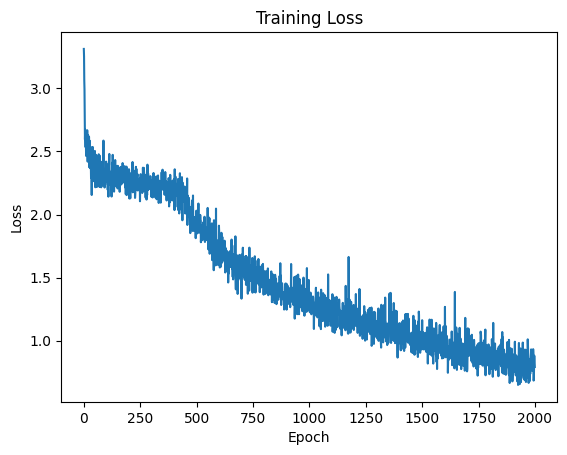

In [79]:
dataset = TranslationDataset(data, src_vocab, tgt_vocab, max_length)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

model = Transformer(len(src_vocab), len(tgt_vocab), embed_size, num_heads, num_layers, max_length)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss(ignore_index=tgt_vocab["<PAD>"])  # Игнорируем 

losses = []
for epoch in range(num_epochs):
    total_loss = 0
    for src, tgt in dataloader:
        src_mask, tgt_mask, memory_mask = create_masks(src, tgt[:, :-1])
        output = model(src, tgt[:, :-1], src_mask, tgt_mask, memory_mask)
        loss = criterion(output.reshape(-1, output.size(-1)), tgt[:, 1:].reshape(-1))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    losses.append(total_loss / len(dataloader))
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch + 1}, Loss: {losses[-1]:.4f}")

# График потерь
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

In [99]:
# Определяем устройство (GPU если доступно, иначе CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Перемещаем модель на устройство
model = model.to(device)

import matplotlib.pyplot as plt
import seaborn as sns

def translate(model, sentence, src_vocab, tgt_vocab, max_length=10, return_figure=False):
    model.eval()
    words = sentence.split()
    tokens = [src_vocab.get(word, src_vocab["<UNK>"]) for word in words][:max_length-2]
    tokens = [src_vocab["<SOS>"]] + tokens + [src_vocab["<EOS>"]]
    src = torch.tensor(tokens, dtype=torch.long).unsqueeze(0).to(device)
    tgt = torch.tensor([[tgt_vocab["<SOS>"]]], dtype=torch.long).to(device)

    src_mask = (src != src_vocab["<PAD>"]).unsqueeze(1).unsqueeze(2)
    memory_mask = src_mask

    generated = []
    all_attentions = []  # сохраним внимания для каждого шага генерации

    for _ in range(max_length):
        tgt_len = tgt.size(1)
        tgt_pad_mask = (tgt != tgt_vocab["<PAD>"]).unsqueeze(1)
        look_ahead_mask = torch.tril(torch.ones((tgt_len, tgt_len), device=device)).bool()
        tgt_mask = tgt_pad_mask & look_ahead_mask

        with torch.no_grad():
            # Запрашиваем возврат attentions
            output, attn_list = model(src, tgt, src_mask, tgt_mask, memory_mask, return_attentions=True)
            # attn_list — список из num_layers тензоров [batch, num_heads, tgt_len, src_len]
            # Возьмём последний слой и первую голову для визуализации
            last_layer_attn = attn_list[-1]  # [1, num_heads, tgt_len, src_len]
            # Усредним по головам или возьмём первую (head=0)
            attn_matrix = last_layer_attn[0, 0].cpu().numpy()  # [tgt_len, src_len]
            all_attentions.append(attn_matrix)

            next_token = output[0, -1, :].argmax().item()

        if next_token == tgt_vocab["<EOS>"]:
            break

        tgt = torch.cat([tgt, torch.tensor([[next_token]], device=device)], dim=1)
        generated.append(tgt_idx_to_word.get(next_token, "<UNK>"))

    # Визуализируем attention последнего сгенерированного токена (или накопленное)
    if generated and all_attentions and return_figure:
        # Берём матрицу для последнего шага (когда сгенерировано последнее слово)
        final_attn = all_attentions[-1]  # форма [tgt_len, src_len]
        # Обрежем до реальной длины исходного предложения
        src_words_with_special = ["<SOS>"] + words + ["<EOS>"]
        tgt_words_with_special = ["<SOS>"] + generated + ["<EOS>"]

        # Матрица внимания имеет размер (текущая длина tgt) x (длина src)
        # Мы покажем внимание для всех сгенерированных токенов (включая <SOS>)
        plt.figure(figsize=(10, 6))
        sns.heatmap(final_attn, 
                    xticklabels=src_words_with_special, 
                    yticklabels=tgt_words_with_special,
                    cmap="viridis")
        plt.xlabel("Source words")
        plt.ylabel("Generated words (incl. <SOS>)")
        plt.title("Cross-attention weights (last decoder layer, head 0)")
        plt.show()
    elif return_figure == False: 
        None
    else:
        print("No words generated, cannot plot attention.")

    return " ".join(generated)

# Пример перевода
print("hello", "---", translate(model, "hello", src_vocab, tgt_vocab))
print("friend", "---", translate(model, "friend", src_vocab, tgt_vocab))
print("soldier", "---", translate(model, "soldier", src_vocab, tgt_vocab))
print("my world", "---", translate(model, "my world", src_vocab, tgt_vocab))
print("hello soldier", "---", translate(model, "hello soldier", src_vocab, tgt_vocab))

hello --- bonjour le
friend --- ami
soldier --- soldat
my world --- comment
hello soldier --- bonjour maman


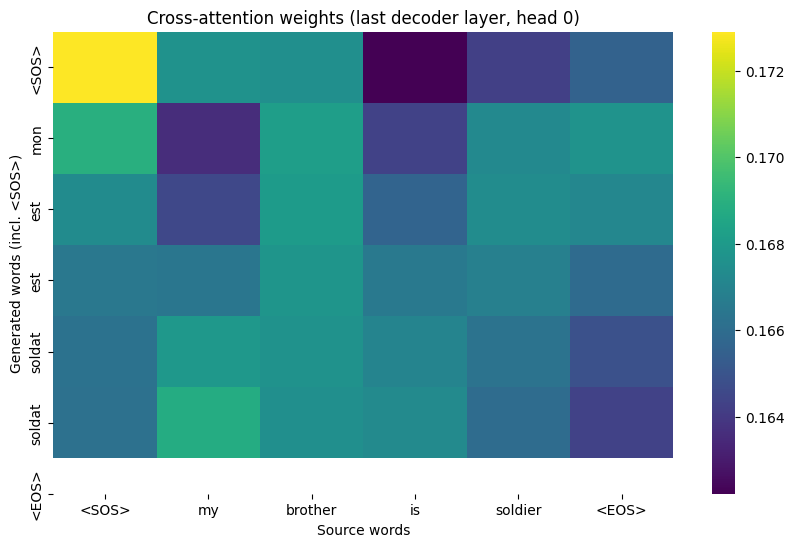

'mon est est soldat soldat'

In [100]:
translate(model, "my brother is soldier", src_vocab, tgt_vocab,10, True)

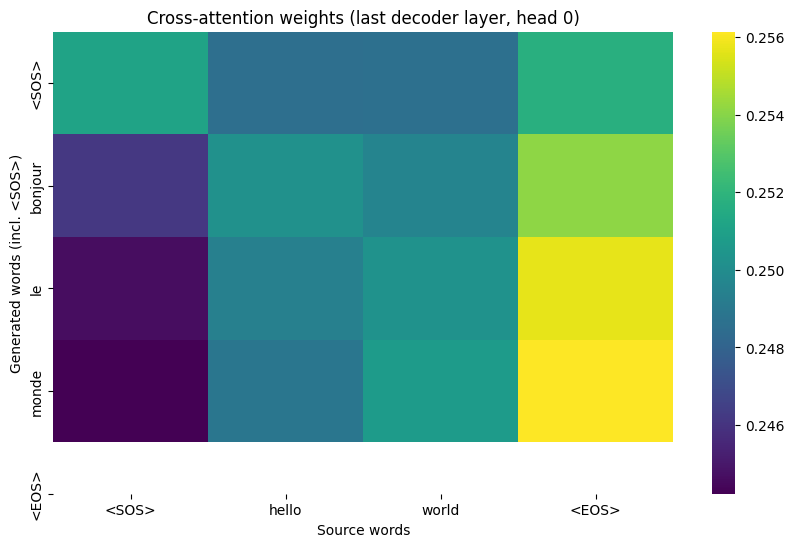

'bonjour le monde'

In [101]:
translate(model, "hello world", src_vocab, tgt_vocab,10, True)

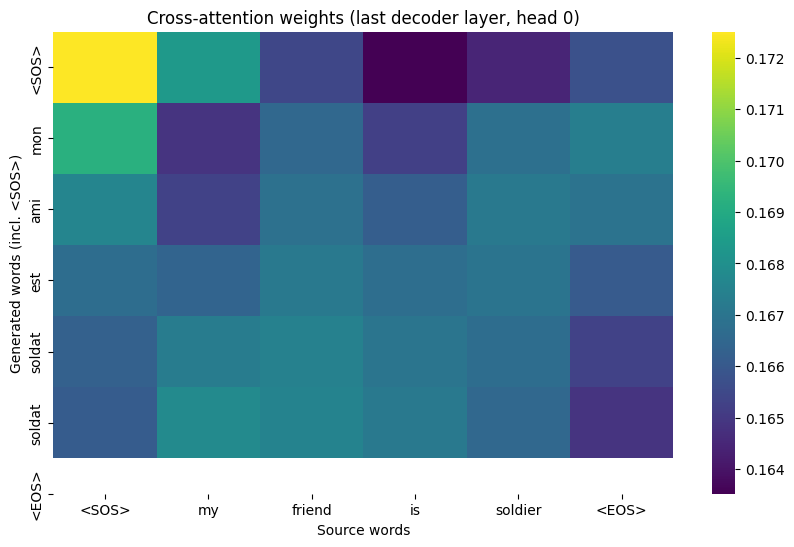

'mon ami est soldat soldat'

In [106]:
translate(model, "my friend is soldier", src_vocab, tgt_vocab,10, True)

In [121]:
for dat in data:
    print('-en:- ', dat[0], '\t-translate:- ',translate(model, dat[0], src_vocab, tgt_vocab), '\t-fr true:-' ,dat[1])

-en:-  hello 	-translate:-  bonjour le 	-fr true:- bonjour
-en:-  soldier 	-translate:-  soldat 	-fr true:- soldat
-en:-  friend 	-translate:-  ami 	-fr true:- ami
-en:-  dear 	-translate:-  cher frère 	-fr true:- cher
-en:-  mom 	-translate:-  maman 	-fr true:- maman
-en:-  how 	-translate:-  comment 	-fr true:- comment
-en:-  my 	-translate:-  est 	-fr true:- mon
-en:-  brother 	-translate:-  frère 	-fr true:- frère
-en:-  world 	-translate:-  bonjour monde 	-fr true:- le monde
-en:-  is 	-translate:-  est 	-fr true:- est
-en:-  hello world 	-translate:-  bonjour le monde 	-fr true:- bonjour le monde
-en:-  how are you 	-translate:-  comment allez-vous 	-fr true:- comment allez-vous
-en:-  my friend is soldier 	-translate:-  mon ami est soldat soldat 	-fr true:- mon ami est soldat
-en:-  dear friend 	-translate:-  cher ami 	-fr true:- cher ami
-en:-  hello mom 	-translate:-  bonjour maman 	-fr true:- bonjour maman
-en:-  mom is soldier 	-translate:-  maman est est soldat 	-fr true:- 